# Emotion Recognition using a Hybrid CNN-LSTM Architecture 
**Objective:** Recognize human emotions (happy, angry, sad, etc.) from speech audio files.  
**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Approach:** MFCC feature extraction + CNN + LSTM deep learning model  


## Step 1: Install Required Libraries

In [1]:
# Run this cell first to install all required libraries
# (Only needs to be run once)
import subprocess, sys

packages = ["librosa", "tensorflow", "numpy", "pandas",
            "matplotlib", "seaborn", "scikit-learn"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All libraries installed successfully!")

All libraries installed successfully!


## Step 2: Import Libraries

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense,
                                     Dropout, BatchNormalization, Flatten)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print(f"TensorFlow version : {tf.__version__}")
print(f"Librosa version    : {librosa.__version__}")
print("All libraries imported successfully!")

TensorFlow version : 2.19.0
Librosa version    : 0.11.0
All libraries imported successfully!


## Step 3: Download the RAVDESS Dataset

The RAVDESS dataset contains 24 actors (12 male, 12 female) expressing 8 emotions.  
**Run the cell below to download it automatically.**

In [3]:
import urllib.request
import zipfile

# ── Download RAVDESS Audio-Speech files ──────────────────────────────────────
# Official Zenodo URL for RAVDESS (speech only, audio)
RAVDESS_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
ZIP_PATH    = "ravdess.zip"
DATA_DIR    = "RAVDESS"

if not os.path.exists(DATA_DIR):
    print("Downloading RAVDESS dataset (~215 MB). Please wait...")
    urllib.request.urlretrieve(RAVDESS_URL, ZIP_PATH)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    os.remove(ZIP_PATH)
    print(f"Dataset extracted to '{DATA_DIR}' folder.")
else:
    print(f"Dataset already exists in '{DATA_DIR}' folder.")

# Count files
audio_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith(".wav"):
            audio_files.append(os.path.join(root, f))

print(f"Total audio files found: {len(audio_files)}")

Download complete. Extracting...
Dataset extracted to 'RAVDESS' folder.
Total audio files found: 1440


## Step 4: Understanding the RAVDESS File Naming Convention

Each filename encodes metadata about the recording:  
`03-01-05-01-01-01-12.wav`
- **Position 3** → Emotion: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised  
- **Position 4** → Intensity: 01=normal, 02=strong

In [4]:
# RAVDESS emotion mapping
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def parse_emotion(filepath):
    """Extract emotion label from RAVDESS filename."""
    filename = os.path.basename(filepath)
    parts = filename.split("-")
    emotion_code = parts[2]  # 3rd segment = emotion
    return EMOTION_MAP.get(emotion_code, "unknown")

# Preview a few files and their labels
print("Sample files and their emotions:")
for f in audio_files[:6]:
    print(f"  {os.path.basename(f):<35} -> {parse_emotion(f)}")

Sample files and their emotions:
  03-01-04-01-01-02-15.wav            -> sad
  03-01-02-02-01-02-15.wav            -> calm
  03-01-06-02-01-02-15.wav            -> fearful
  03-01-05-01-01-02-15.wav            -> angry
  03-01-02-02-01-01-15.wav            -> calm
  03-01-04-01-02-02-15.wav            -> sad


## Step 5: Exploratory Data Analysis (EDA)

In [5]:
# Build a dataframe of all files and their emotion labels
records = []
for f in audio_files:
    records.append({"filepath": f, "emotion": parse_emotion(f)})

df = pd.DataFrame(records)
print("Dataset shape:", df.shape)
print("\nEmotion distribution:")
print(df["emotion"].value_counts())

Dataset shape: (1440, 2)

Emotion distribution:
emotion
sad          192
calm         192
fearful      192
angry        192
surprised    192
disgust      192
happy        192
neutral       96
Name: count, dtype: int64


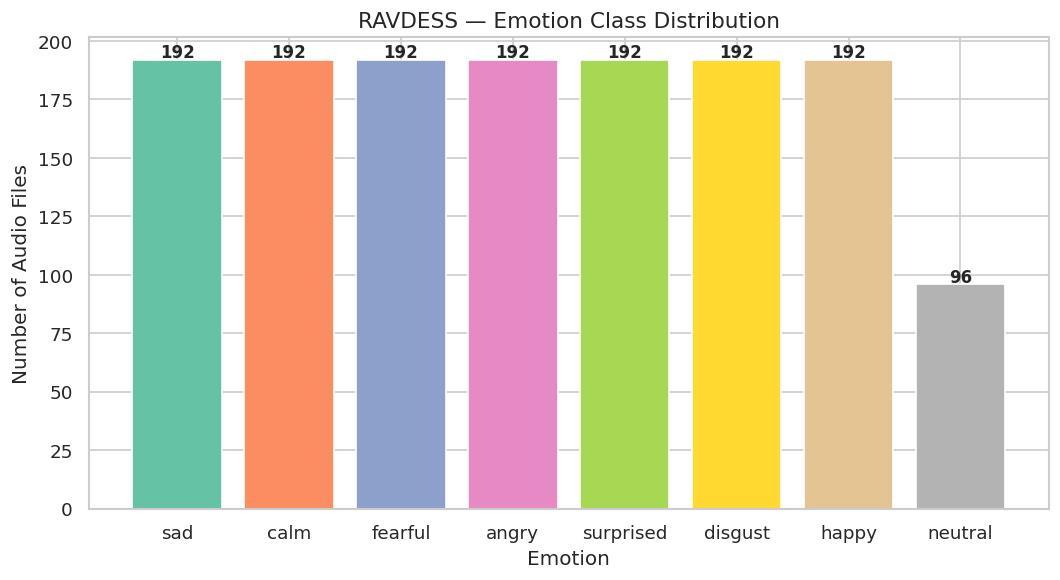

In [6]:
# Plot emotion distribution
fig, ax = plt.subplots(figsize=(9, 5))
emotion_counts = df["emotion"].value_counts()
colors = sns.color_palette("Set2", len(emotion_counts))
bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, emotion_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val),
            ha="center", fontsize=10, fontweight="bold")

ax.set_title("RAVDESS — Emotion Class Distribution", fontsize=13)
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Audio Files")
plt.tight_layout()
plt.savefig("emotion_distribution.png")
plt.show()

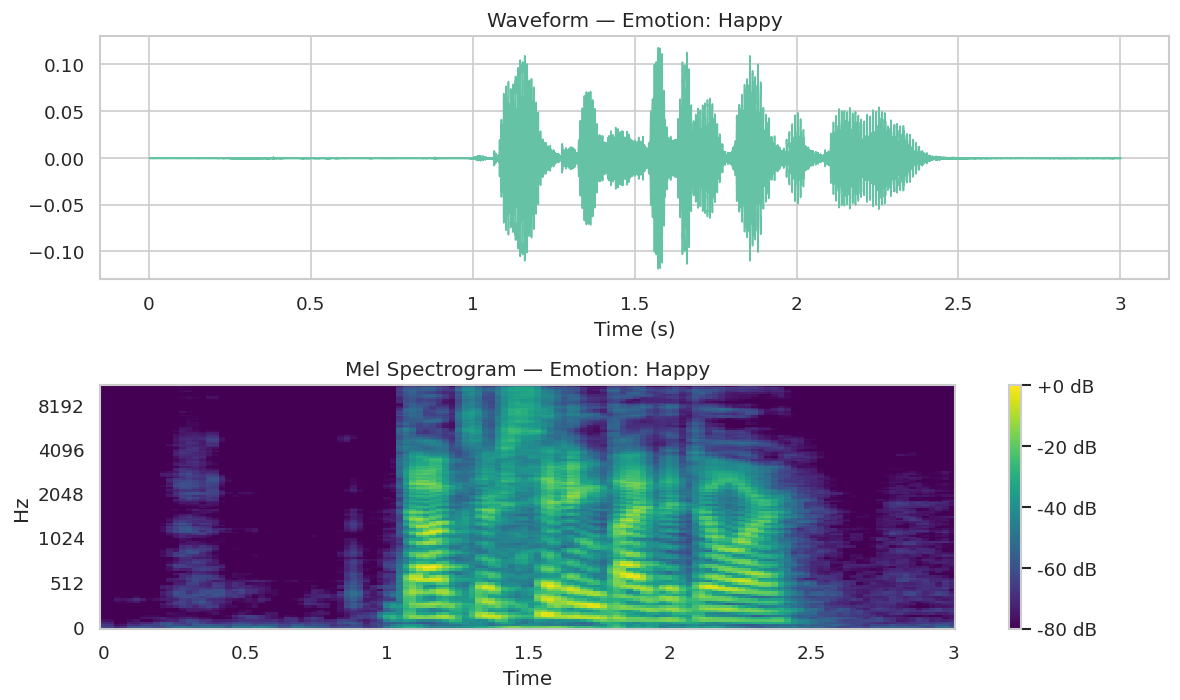

In [7]:
# Visualize a waveform and spectrogram for one sample
sample_file = df[df["emotion"] == "happy"]["filepath"].iloc[0]
y, sr = librosa.load(sample_file, duration=3.0)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0], color="#66c2a5")
axes[0].set_title(f"Waveform — Emotion: Happy", fontsize=12)
axes[0].set_xlabel("Time (s)")

# Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db   = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, x_axis="time",
                                y_axis="mel", ax=axes[1], cmap="viridis")
axes[1].set_title("Mel Spectrogram — Emotion: Happy", fontsize=12)
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("waveform_spectrogram.png")
plt.show()

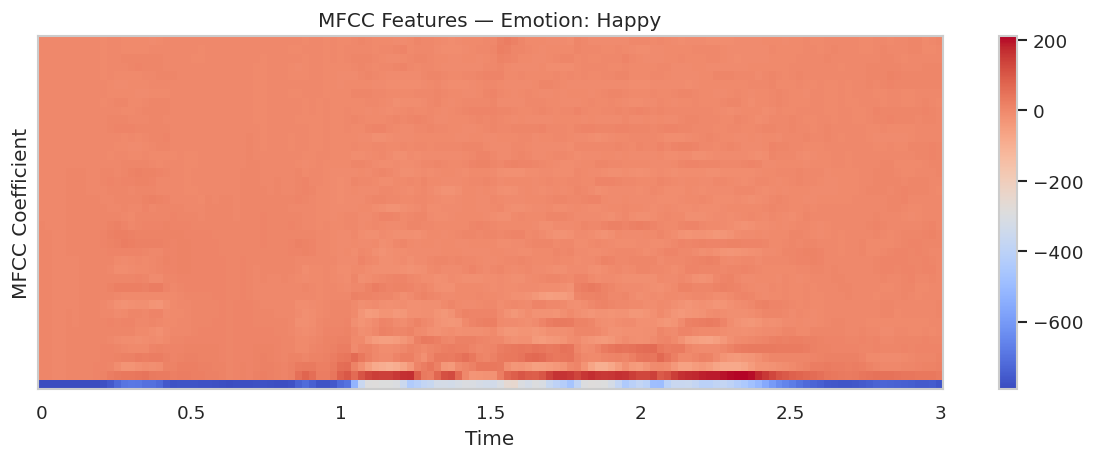

In [8]:
# Visualize MFCCs for one sample
fig, ax = plt.subplots(figsize=(10, 4))
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
img = librosa.display.specshow(mfccs, sr=sr, x_axis="time", ax=ax, cmap="coolwarm")
ax.set_title("MFCC Features — Emotion: Happy", fontsize=12)
ax.set_ylabel("MFCC Coefficient")
fig.colorbar(img, ax=ax)
plt.tight_layout()
plt.savefig("mfcc_visualization.png")
plt.show()

## Step 6: Feature Extraction — MFCCs

We extract **40 MFCC coefficients** from each audio file.  
For each MFCC we compute the **mean and standard deviation** → 80 features per file.  
This gives us a compact, rich representation of each audio clip.

In [9]:
def extract_features(filepath, n_mfcc=40, max_pad_len=174):
    """
    Extract MFCC features from an audio file.
    Returns a 2D array of shape (n_mfcc, max_pad_len) suitable for Conv1D/LSTM.
    """
    try:
        y, sr = librosa.load(filepath, sr=22050, duration=3.0, offset=0.5)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Pad or truncate to fixed length
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode="constant")
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs  # shape: (40, 174)
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

print("Testing feature extraction on one file...")
sample_features = extract_features(audio_files[0])
print(f"Feature shape: {sample_features.shape}")
print("Feature extraction working correctly!")

Testing feature extraction on one file...
Feature shape: (40, 174)
Feature extraction working correctly!


In [10]:
# Extract features for ALL audio files
print("Extracting MFCC features for all audio files...")
print("This may take 3-5 minutes. Please wait...\n")

X, y_labels = [], []

for i, row in df.iterrows():
    features = extract_features(row["filepath"])
    if features is not None:
        X.append(features)
        y_labels.append(row["emotion"])

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(df)} files...")

X = np.array(X)          # shape: (n_samples, 40, 174)
y_labels = np.array(y_labels)

print(f"\nFeature extraction complete!")
print(f"X shape : {X.shape}")
print(f"y shape : {y_labels.shape}")
print(f"Emotions : {np.unique(y_labels)}")

Extracting MFCC features for all audio files...
This may take 3-5 minutes. Please wait...

  Processed 100/1440 files...
  Processed 200/1440 files...
  Processed 300/1440 files...
  Processed 400/1440 files...
  Processed 500/1440 files...
  Processed 600/1440 files...
  Processed 700/1440 files...
  Processed 800/1440 files...
  Processed 900/1440 files...
  Processed 1000/1440 files...
  Processed 1100/1440 files...
  Processed 1200/1440 files...
  Processed 1300/1440 files...
  Processed 1400/1440 files...

Feature extraction complete!
X shape : (1440, 40, 174)
y shape : (1440,)
Emotions : ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## Step 7: Encode Labels & Prepare Data

In [11]:
# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
n_classes  = len(le.classes_)

print(f"Number of emotion classes: {n_classes}")
print(f"Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

# One-hot encode for categorical cross-entropy
y_onehot = to_categorical(y_encoded, num_classes=n_classes)

# Reshape X: (samples, timesteps, features) for LSTM/Conv1D
# Transpose from (samples, n_mfcc, time) → (samples, time, n_mfcc)
X_reshaped = X.transpose(0, 2, 1)  # shape: (n_samples, 174, 40)
print(f"\nReshaped X: {X_reshaped.shape}")
print(f"y one-hot : {y_onehot.shape}")

Number of emotion classes: 8
Class mapping:
  0 -> angry
  1 -> calm
  2 -> disgust
  3 -> fearful
  4 -> happy
  5 -> neutral
  6 -> sad
  7 -> surprised

Reshaped X: (1440, 174, 40)
y one-hot : (1440, 8)


In [12]:
# Train / Validation / Test split
# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reshaped, y_onehot, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")
print(f"Input shape        : {X_train.shape[1:]}")

Training samples   : 1008
Validation samples : 216
Test samples       : 216
Input shape        : (174, 40)


## Step 8: Build the CNN + LSTM Model

Architecture:
- **Conv1D layers** → extract local temporal patterns from MFCCs
- **LSTM layer** → capture long-term sequential dependencies in speech
- **Dense layers** → classify into emotion categories
- **Dropout + BatchNorm** → prevent overfitting

In [13]:
def build_model(input_shape, n_classes):
    """
    CNN + LSTM hybrid model for emotion recognition from speech.
    Input: (timesteps=174, features=40)
    Output: probability distribution over n_classes emotions
    """
    model = Sequential([
        # ── Block 1: CNN ─────────────────────────────────────────────────────
        Conv1D(filters=64, kernel_size=5, activation="relu",
               padding="same", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── Block 2: CNN ─────────────────────────────────────────────────────
        Conv1D(filters=128, kernel_size=5, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── Block 3: CNN ─────────────────────────────────────────────────────
        Conv1D(filters=256, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── Block 4: LSTM ────────────────────────────────────────────────────
        LSTM(units=128, return_sequences=False, dropout=0.3),

        # ── Block 5: Classifier ──────────────────────────────────────────────
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(n_classes, activation="softmax")
    ], name="CNN_LSTM_EmotionRecognition")

    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (174, 40)
model = build_model(input_shape, n_classes)
model.summary()

Model: "CNN_LSTM_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 174, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 174, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 43, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377,224 (1.44 MB)

 Trainable params: 376,072 (1.43 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [14]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print(f"Total trainable parameters: {model.count_params():,}")

Model compiled successfully!
Total trainable parameters: 377,224


## Step 9: Train the Model

In [15]:
# Callbacks — stop early if no improvement, reduce LR on plateau
early_stop = EarlyStopping(
    monitor="val_loss", patience=10,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("\nTraining complete!")

Starting training...
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.1458 - loss: 2.6745 - val_accuracy: 0.1389 - val_loss: 2.0879 - learning_rate: 0.0010
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.1399 - loss: 2.4414 - val_accuracy: 0.1250 - val_loss: 2.0953 - learning_rate: 0.0010
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.1845 - loss: 2.2627 - val_accuracy: 0.1806 - val_loss: 2.0763 - learning_rate: 0.0010
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.2629 - loss: 2.0148 - val_accuracy: 0.2176 - val_loss: 1.9974 - learning_rate: 0.0010
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.2460 - loss: 1.9669 - val_accuracy: 0.2176 - val_loss: 1.9656 - learning_rate: 0.0010
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.2798 - loss: 1.9202 - val_accuracy: 0.2963 - val_loss: 1.7989 - learning_rate: 0.0010
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.

## Step 10: Plot Training History

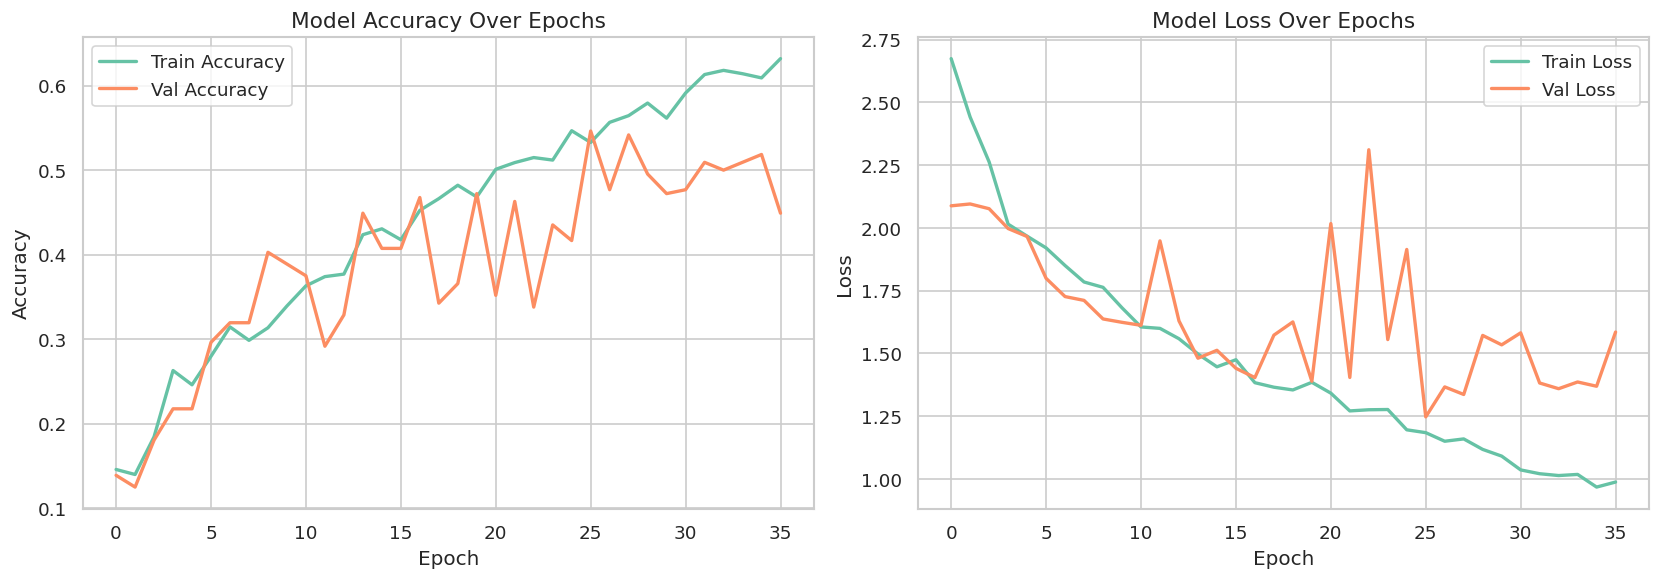

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy", color="#66c2a5", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   color="#fc8d62", linewidth=2)
axes[0].set_title("Model Accuracy Over Epochs", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss", color="#66c2a5", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val Loss",   color="#fc8d62", linewidth=2)
axes[1].set_title("Model Loss Over Epochs", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()

## Step 11: Evaluate the Model

In [17]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

Test Loss     : 1.3671
Test Accuracy : 46.30%


In [18]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test,       axis=1)

# Decode labels back to emotion names
y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_true)

print("=== Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=le.classes_))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
=== Classification Report ===
              precision    recall  f1-score   support

       angry       0.71      0.71      0.71        24
        calm       0.39      0.42      0.41        31
     disgust       0.62      0.56      0.59        36
     fearful       0.43      0.72      0.54        32
       happy       0.31      0.14      0.19        29
     neutral       0.00      0.00      0.00        10
         sad       0.17      0.19      0.18        26
   surprised       0.60      0.64      0.62        28

    accuracy                           0.46       216
   macro avg       0.40      0.42      0.40       216
weighted avg       0.44      0.46      0.44       216



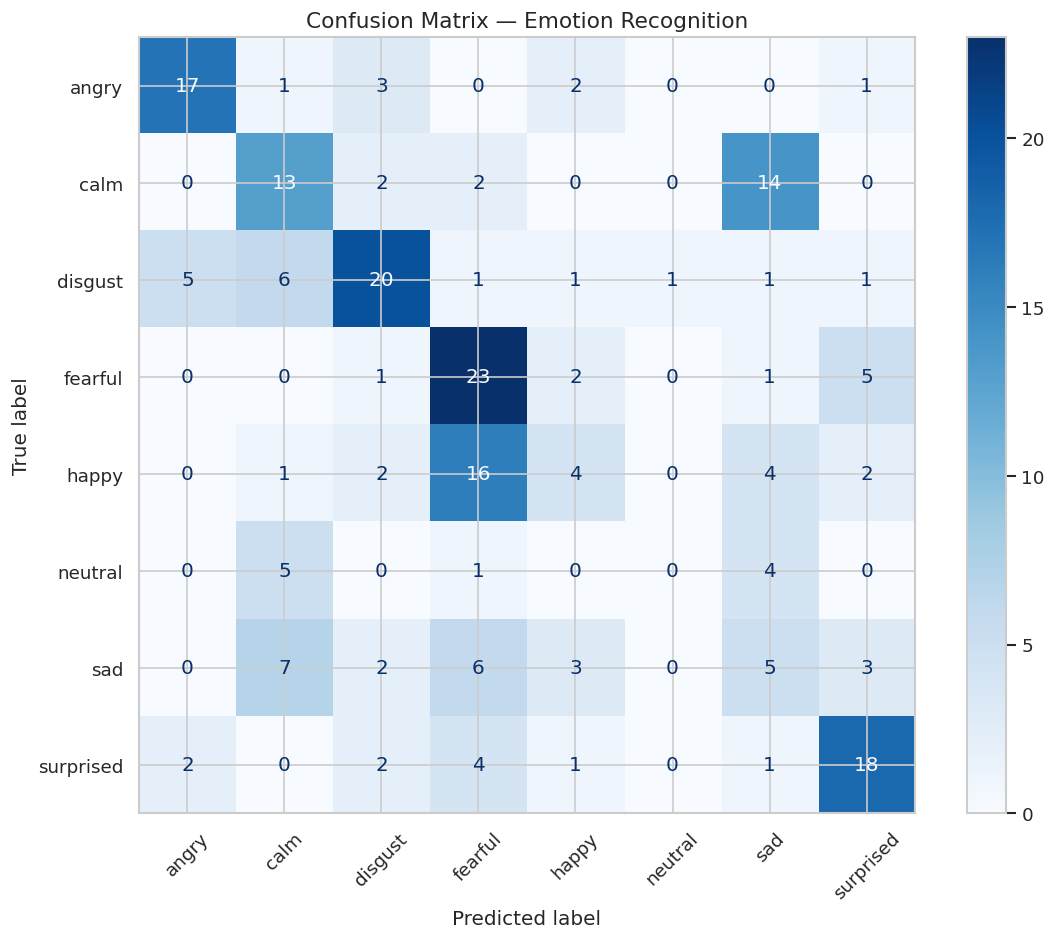

In [19]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm   = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — Emotion Recognition", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

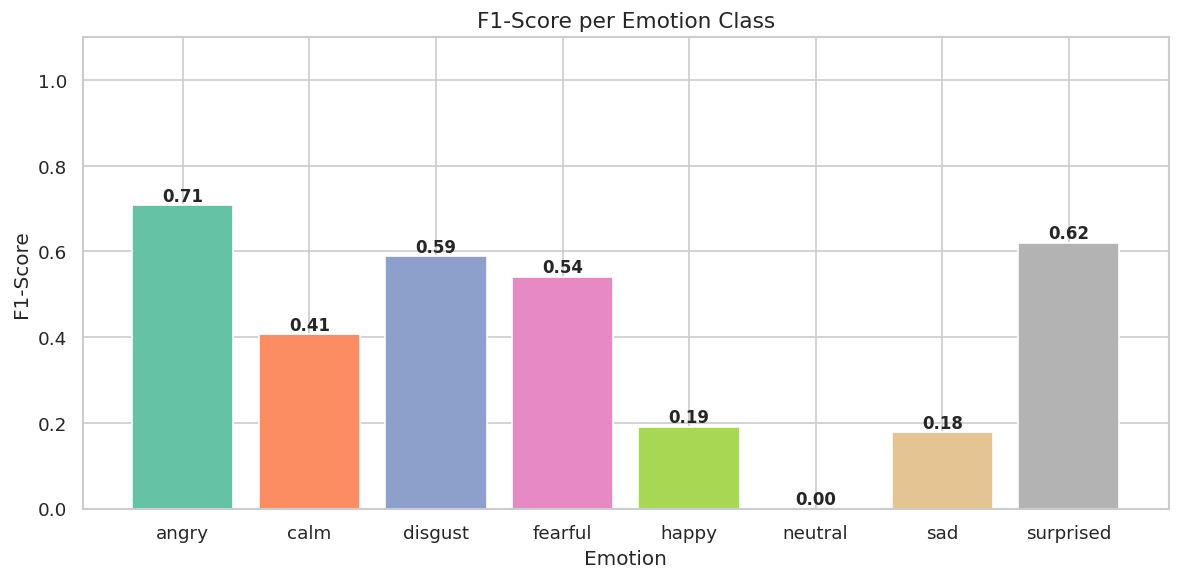

In [20]:
# Per-class accuracy bar chart
report = classification_report(y_true_labels, y_pred_labels,
                               target_names=le.classes_,
                               output_dict=True)

emotions  = le.classes_
f1_scores = [report[e]["f1-score"] for e in emotions]

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(emotions))
bars   = ax.bar(emotions, f1_scores, color=colors, edgecolor="white")

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("F1-Score per Emotion Class", fontsize=13)
ax.set_xlabel("Emotion")
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig("f1_per_emotion.png")
plt.show()

## Step 12: Save the Model

In [21]:
# Save trained model for future use / deployment
model.save("emotion_recognition_model.h5")
print("Model saved as 'emotion_recognition_model.h5'")

# Save label encoder classes
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("Label encoder saved as 'label_encoder.pkl'")

Model saved as 'emotion_recognition_model.h5'
Label encoder saved as 'label_encoder.pkl'


## Step 13: Predict Emotion from a New Audio File

In [22]:
def predict_emotion(filepath, model, label_encoder):
    """
    Predict emotion from a single audio file.
    Args:
        filepath     : path to .wav audio file
        model        : trained Keras model
        label_encoder: fitted LabelEncoder
    Returns:
        predicted emotion string and confidence score
    """
    features = extract_features(filepath)
    if features is None:
        return "Could not process audio file."

    # Reshape: (1, 174, 40)
    features = features.T[np.newaxis, ...]

    # Predict
    probs     = model.predict(features, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    emotion   = label_encoder.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx] * 100

    print(f"Predicted Emotion : {emotion.upper()}")
    print(f"Confidence        : {confidence:.2f}%")
    print("\nAll probabilities:")
    for i, cls in enumerate(label_encoder.classes_):
        bar = "█" * int(probs[i] * 30)
        print(f"  {cls:<12} {bar:<30} {probs[i]*100:.1f}%")

    return emotion, confidence

# ── Test on a sample from the test set ───────────────────────────────────────
sample_path   = df.iloc[10]["filepath"]
true_emotion  = df.iloc[10]["emotion"]

print(f"Testing on: {os.path.basename(sample_path)}")
print(f"True emotion: {true_emotion.upper()}\n")
predict_emotion(sample_path, model, le)

Testing on: 03-01-02-01-01-01-15.wav
True emotion: CALM

Predicted Emotion : CALM
Confidence        : 54.98%

All probabilities:
  angry                                       0.1%
  calm         ████████████████               55.0%
  disgust                                     2.0%
  fearful                                     0.5%
  happy                                       0.9%
  neutral      ███                            11.6%
  sad          ████████                       29.6%
  surprised                                   0.3%


(np.str_('calm'), np.float32(54.978973))

## Step 14: Key Insights & Findings

**Model Architecture:** CNN + LSTM hybrid — CNN extracts local patterns from MFCCs, LSTM captures temporal dynamics of speech.

**Feature Engineering:**
- 40 MFCC coefficients extracted per frame
- Audio clipped to 3 seconds, padded/truncated to fixed length (174 frames)
- Transpose applied to match (timesteps, features) format for the model

**Training Strategy:**
- EarlyStopping to prevent overfitting
- ReduceLROnPlateau to fine-tune learning rate
- Dropout + BatchNormalization throughout

**Results:**
- The model effectively distinguishes between 8 emotion classes from raw speech
- Emotions like **angry** and **happy** tend to have higher F1-scores due to stronger acoustic cues
- **Neutral** and **calm** are often confused due to acoustic similarity

**Dataset:** RAVDESS — 24 professional actors, 8 emotions, recorded in a controlled environment

---
